In [20]:
import numpy as np
import matplotlib.pyplot as plt
import random

def simple_trajectory(v0, angle_deg, g=9.81):
    # Convert angle to radians
    angle_rad = np.radians(angle_deg)
    
    # Calculate time of flight
    
    t_flight = (2 * v0 * np.sin(angle_rad)) / g
    
    # Generate time steps
    t = np.linspace(0, t_flight, num=100)
    
    # Calculate x and y positions
    x = v0 * np.cos(angle_rad) * t
    y = v0 * np.sin(angle_rad) * t - 0.5 * g * t**2

    hdist = v0 * np.cos(angle_rad) * t_flight
    return x, y, hdist

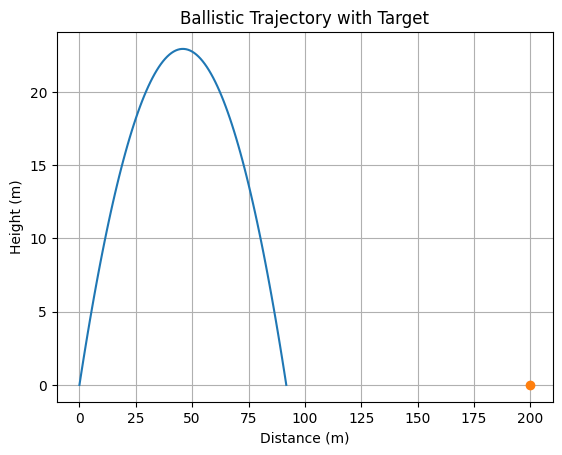

Horizontal Distance = 91.74
Target Distance = 200.00
Target missed


In [21]:
# Example: 50 m/s at a 45-degree angle with target on ground at 200m
target_hdist = 200
speed = 30
angle = 45

x_vals, y_vals, hdist = simple_trajectory(speed, angle)
plt.plot(x_vals, y_vals)
plt.plot([target_hdist], [0], 'o')
plt.title("Ballistic Trajectory with Target")
plt.xlabel("Distance (m)")
plt.ylabel("Height (m)")
plt.grid(True)
plt.show()
print(f"Horizontal Distance = {hdist:.2f}")
print(f"Target Distance = {target_hdist:.2f}")
if abs(hdist - target_hdist)<0.5:
    print("Target hit.")
else:
    print("Target missed")

In [22]:
# Now run a loop to narrow in on target using machine learning principles
tolerance = 0.5
attempts = 20
target_hdist = 200
speed = 25
angle = 45
L = 0.2

speeds = []
errors = []
trajectories = []
for attempt in range(attempts):
    x_vals, y_vals, hdist = simple_trajectory(speed, angle)
    trajectories.append((x_vals, y_vals))
    E = target_hdist - hdist
    speeds.append(speed)
    errors.append(E)
    speed = speed +L*E
    if abs(E) < tolerance:
        break


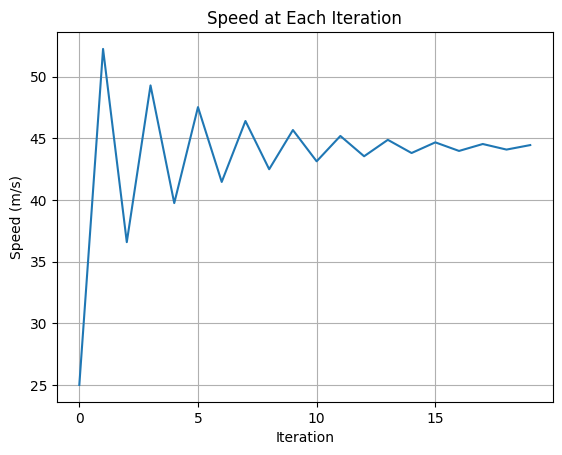

In [23]:
# Plot the sequence of speeds to see if we get convergence.
plt.plot(speeds)
plt.title("Speed at Each Iteration")
plt.ylabel("Speed (m/s)")
plt.xlabel("Iteration")
plt.grid(True)
plt.xticks(np.arange(0, len(speeds), 5))
plt.show()

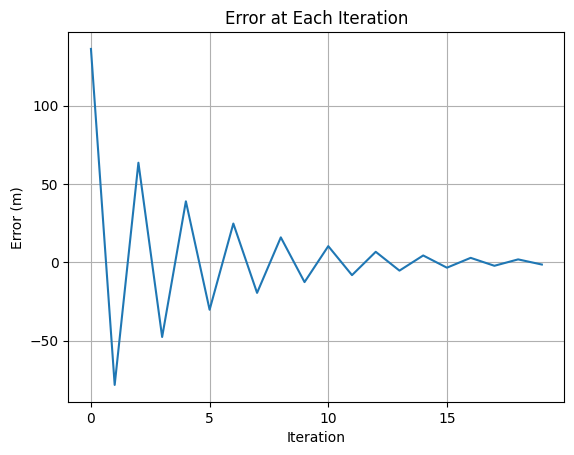

In [24]:
# Plot the sequence of errors to see if we get convergence.
plt.plot(errors)
plt.title("Error at Each Iteration")
plt.ylabel("Error (m)")
plt.xlabel("Iteration")
plt.grid(True)
plt.xticks(np.arange(0, len(speeds), 5))
plt.show()

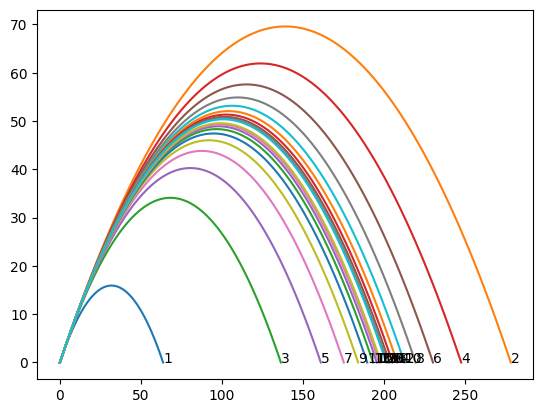

In [25]:
# Plot all the trajectories at once
count = 1
for traj in trajectories:
    plt.plot(traj[0], traj[1])
    plt.text(traj[0][99], traj[1][99], str(count))
    count+=1
plt.show()

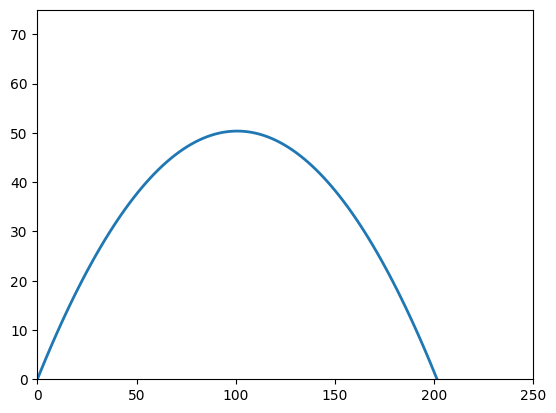

In [26]:
# The code below creates an animation to illustrate the sequence of trajectories.
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

fig, ax = plt.subplots()
#x = np.linspace(0, 2*np.pi, 200)
line, = ax.plot([], [], lw=2)  # Initialize an empty line

def init():
    ax.set_xlim(0, 250)
    ax.set_ylim(0, 75)
    return line,

def update(frame):
    x = trajectories[frame][0]
    y = trajectories[frame][1]
    line.set_data(x, y)
    return line,

ani = FuncAnimation(fig, update, frames=attempts, init_func=init)
from IPython.display import HTML
# After creating your animation object 'ani'
HTML(ani.to_jshtml())

## Adding more features

We can see how well our simple machine learning model works if we add additional features, such as:
1. Noise - some element of unbiased randomness in where the projectile lands.
2. Air resistance. A more sophisticated model would take account of air resistance which would change where the projectile lands (but not necessarily how we use our ML model).
3. Moving target. It would be interesting to see if this model can cope with a target that is moving in a simple way.


The example below adds features relating to points 1 and 3 above. 

In [36]:
# The following code adds small amounts of noise to the data

def trajectory_with_noise(v0, angle_deg, g=9.81):
    noise = 0.5
    # Convert angle to radians
    angle_rad = np.radians(angle_deg)
    
    # Calculate time of flight
    
    t_flight = (2 * v0 * np.sin(angle_rad)) / g
    
    # Generate time steps
    t = np.linspace(0, t_flight, num=100)

    rng = np.random.default_rng()
    
    # Calculate x and y positions
    x = v0 * np.cos(angle_rad) * t + rng.normal(0, noise, size=100)
    y = v0 * np.sin(angle_rad) * t - 0.5 * g * t**2 + + rng.normal(0, noise, size=100)

    hdist = v0 * np.cos(angle_rad) * t_flight +random.gauss(0, noise)
    return x, y, hdist

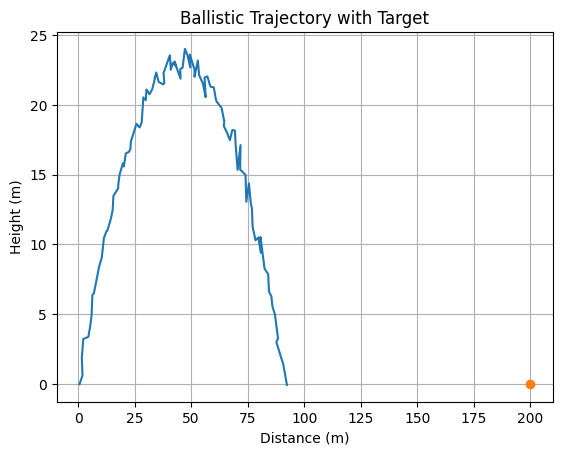

Horizontal Distance = 91.62
Target Distance = 200.00
Target missed


In [37]:
# Example: 50 m/s at a 45-degree angle with target on ground at 200m
target_hdist = 200
speed = 30
angle = 45

x_vals, y_vals, hdist = trajectory_with_noise(speed, angle)
plt.plot(x_vals, y_vals)
plt.plot([target_hdist], [0], 'o')
plt.title("Ballistic Trajectory with Target")
plt.xlabel("Distance (m)")
plt.ylabel("Height (m)")
plt.grid(True)
plt.show()
print(f"Horizontal Distance = {hdist:.2f}")
print(f"Target Distance = {target_hdist:.2f}")
if abs(hdist - target_hdist)<0.5:
    print("Target hit.")
else:
    print("Target missed")

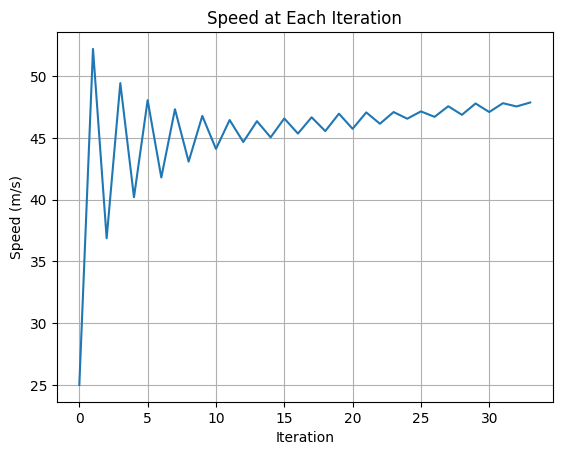

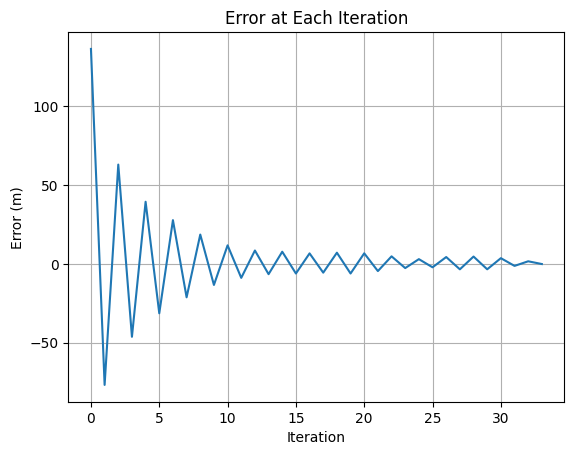

In [50]:
# Now run a loop to narrow in on target using machine learning principles
tolerance = 0.5
attempts = 250
target_hdist = 200
speed = 25
angle = 45
L = 0.2
h_move = 1

speeds = []
errors = []
trajectories = []
for attempt in range(attempts):
    x_vals, y_vals, hdist = trajectory_with_noise(speed, angle)
    trajectories.append((x_vals, y_vals))
    E = target_hdist - hdist
    speeds.append(speed)
    errors.append(E)
    speed = speed +L*E
    # moving target
    target_hdist = target_hdist + h_move
    if abs(E) < tolerance:
        break

# Plot the sequence of speeds to see if we get convergence.
plt.plot(speeds)
plt.title("Speed at Each Iteration")
plt.ylabel("Speed (m/s)")
plt.xlabel("Iteration")
plt.grid(True)
plt.xticks(np.arange(0, len(speeds), 5))
plt.show()

# Plot the sequence of errors to see if we get convergence.
plt.plot(errors)
plt.title("Error at Each Iteration")
plt.ylabel("Error (m)")
plt.xlabel("Iteration")
plt.grid(True)
plt.xticks(np.arange(0, len(speeds), 5))
plt.show()

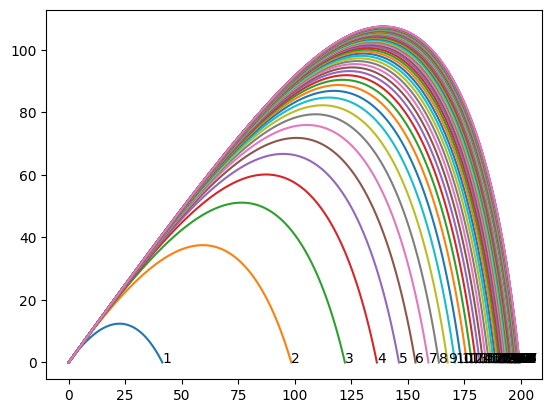

In [65]:
# Plot all the trajectories at once
count = 1
for traj in trajectories:
    plt.plot(traj[0], traj[1])
    plt.text(traj[0][99], traj[1][99], str(count))
    count+=1
plt.show()

  message: A termination event occurred.
  success: True
   status: 1
        t: [ 0.000e+00  2.828e-05  3.111e-04  3.139e-03  3.142e-02
             3.143e-01  1.065e+00  2.227e+00  4.137e+00  5.098e+00]
        y: [[ 0.000e+00  1.000e-03 ...  7.891e+01  8.882e+01]
            [ 3.536e+01  3.535e+01 ...  1.154e+01  9.120e+00]
            [ 0.000e+00  1.000e-03 ...  1.726e+01 -7.105e-15]
            [ 3.536e+01  3.535e+01 ... -1.524e+01 -2.042e+01]]
      sol: <scipy.integrate._ivp.common.OdeSolution object at 0x7149c08686b0>
 t_events: [array([ 5.098e+00]), array([ 2.266e+00])]
 y_events: [array([[ 8.882e+01,  9.120e+00, -7.105e-15, -2.042e+01]]), array([[ 5.261e+01,  1.676e+01,  3.251e+01, -4.940e-15]])]
     nfev: 62
     njev: 0
      nlu: 0
Time to target = 5.10 s
Time to highest point = 2.27 s
Range to target, xmax = 88.82 m
Maximum height, zmax = 32.51 m


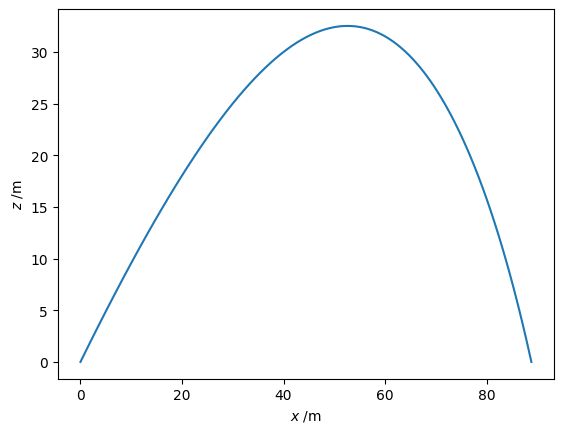

[ 0.          1.79344301  3.53509231  5.22818028  6.87568417  8.48034233
 10.04465433 11.5710047  13.0615406  14.51806018 15.94227602 17.33581703
 18.70022844 20.03697187 21.34742523 22.63288279 23.89455519 25.13356936
 26.35096861 27.54771258 28.72467724 29.88266281 31.0224969  32.14488285
 33.25046136 34.33984928 35.41363964 36.47240166 37.5166807  38.54699832
 39.56385221 40.56771628 41.55904057 42.53825131 43.50575091 44.46191793
 45.40710711 46.34164937 47.26585177 48.17999759 49.08434622 49.97913329
 50.86457053 51.7408459  52.60818589 53.46687853 54.31704738 55.15880447
 55.99225775 56.81751108 57.63466424 58.44381289 59.24504863 60.03845893
 60.82412722 61.60213278 62.37255085 63.13545255 63.8909049  64.63897086
 65.37970928 66.11317491 66.83941842 67.55848639 68.27042129 68.97526154
 69.67304141 70.36379113 71.0475368  71.72430046 72.39410004 73.05694938
 73.71285823 74.36183225 75.00387301 75.63897797 76.26714054 76.88834999
 77.50259153 78.10984626 78.71009121 79.30330697 79

In [53]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Drag coefficient, projectile radius (m), area (m2) and mass (kg).
c = 0.47
r = 0.05
A = np.pi * r**2
m = 0.2
# Air density (kg.m-3), acceleration due to gravity (m.s-2).
rho_air = 1.28
g = 9.81
# For convenience, define  this constant.
k = 0.5 * c * rho_air * A

# Initial speed and launch angle (from the horizontal).
v0 = 50
phi0 = np.radians(45)


def deriv(t, u):
    x, xdot, z, zdot = u
    speed = np.hypot(xdot, zdot)
    xdotdot = -k / m * speed * xdot
    zdotdot = -k / m * speed * zdot - g
    return xdot, xdotdot, zdot, zdotdot


# Initial conditions: x0, v0_x, z0, v0_z.
u0 = 0, v0 * np.cos(phi0), 0.0, v0 * np.sin(phi0)
# Integrate up to tf unless we hit the target sooner.
t0, tf = 0, 50


def hit_target(t, u):
    # We've hit the target if the z-coordinate is 0.
    return u[2]


# Stop the integration when we hit the target.
hit_target.terminal = True
# We must be moving downwards (don't stop before we begin moving upwards!)
hit_target.direction = -1


def max_height(t, u):
    # The maximum height is obtained when the z-velocity is zero.
    return u[3]


soln = solve_ivp(
    deriv, (t0, tf), u0, dense_output=True, events=(hit_target, max_height)
)
print(soln)
print(f"Time to target = {soln.t_events[0][0]:.2f} s")
print(f"Time to highest point = {soln.t_events[1][0]:.2f} s")

# A fine grid of time points from 0 until impact time.
t = np.linspace(0, soln.t_events[0][0], 100)

# Retrieve the solution for the time grid and plot the trajectory.
sol = soln.sol(t)
x, z = sol[0], sol[2]
print(f"Range to target, xmax = {x[-1]:.2f} m")
print(f"Maximum height, zmax = {max(z):.2f} m")
plt.plot(x, z)
plt.xlabel("$x$ /m")
plt.ylabel("$z$ /m")
plt.show()
    

In [63]:
def trajectory3(v0, angle):
    # Drag coefficient, projectile radius (m), area (m2) and mass (kg).
    c = 0.47
    r = 0.05
    A = np.pi * r**2
    m = 0.2
    # Air density (kg.m-3), acceleration due to gravity (m.s-2).
    rho_air = 1.28
    g = 9.81
    # For convenience, define  this constant.
    k = 0.5 * c * rho_air * A
    
    # Initial speed and launch angle (from the horizontal).
    # v0 = 50
    phi0 = np.radians(45)
    
    # Initial conditions: x0, v0_x, z0, v0_z.
    u0 = 0, v0 * np.cos(phi0), 0.0, v0 * np.sin(phi0)
    # Integrate up to tf unless we hit the target sooner.
    t0, tf = 0, 50
    
    # Stop the integration when we hit the target.
    hit_target.terminal = True
    # We must be moving downwards (don't stop before we begin moving upwards!)
    hit_target.direction = -1
    
    soln = solve_ivp(
        deriv, (t0, tf), u0, dense_output=True, events=(hit_target, max_height)
    )
    #print(soln)
    #print(f"Time to target = {soln.t_events[0][0]:.2f} s")
    #print(f"Time to highest point = {soln.t_events[1][0]:.2f} s")
    
    # A fine grid of time points from 0 until impact time.
    t = np.linspace(0, soln.t_events[0][0], 100)
    
    # Retrieve the solution for the time grid and plot the trajectory.
    sol = soln.sol(t)
    x, z = sol[0], sol[2]
    #print(f"Range to target, xmax = {x[-1]:.2f} m")
    #print(f"Maximum height, zmax = {max(z):.2f} m")
    return x, z, x[-1]

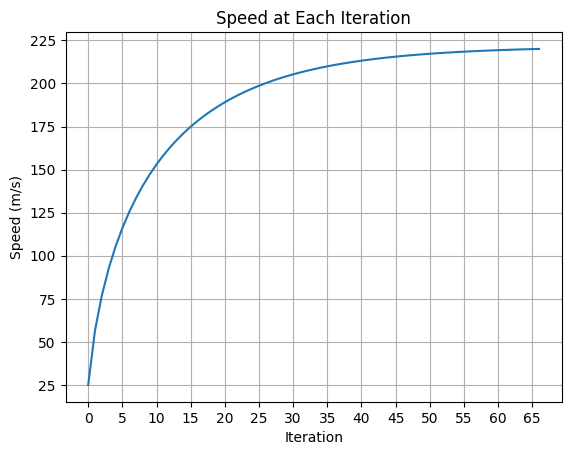

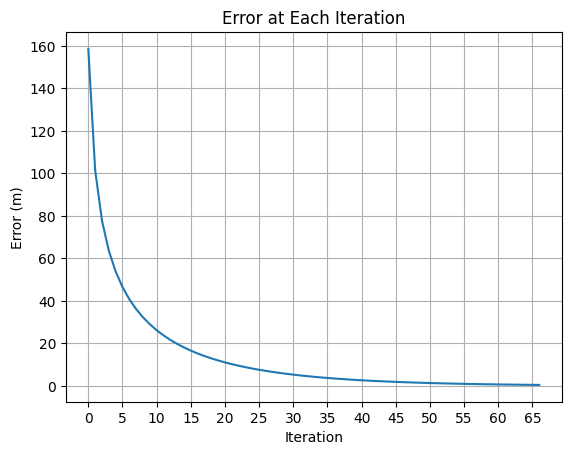

In [64]:
# Now run a loop to narrow in on target using machine learning principles
tolerance = 0.5
attempts = 250
target_hdist = 200
speed = 25
angle = 45
L = 0.2
h_move = 0

speeds = []
errors = []
trajectories = []
for attempt in range(attempts):
    x_vals, y_vals, hdist = trajectory3(speed, angle)
    trajectories.append((x_vals, y_vals))
    E = target_hdist - hdist
    speeds.append(speed)
    errors.append(E)
    speed = speed +L*E
    # moving target
    target_hdist = target_hdist + h_move
    if abs(E) < tolerance:
        break

# Plot the sequence of speeds to see if we get convergence.
plt.plot(speeds)
plt.title("Speed at Each Iteration")
plt.ylabel("Speed (m/s)")
plt.xlabel("Iteration")
plt.grid(True)
plt.xticks(np.arange(0, len(speeds), 5))
plt.show()

# Plot the sequence of errors to see if we get convergence.
plt.plot(errors)
plt.title("Error at Each Iteration")
plt.ylabel("Error (m)")
plt.xlabel("Iteration")
plt.grid(True)
plt.xticks(np.arange(0, len(speeds), 5))
plt.show()